In [ ]:
!pip install numpy
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install umap-learn[plot]
!pip install pyconll

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 6.7 MB/s eta 0:00:00


In [ ]:
from statistics import linear_regression
from sklearn import svm
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelBinarizer


from sklearn.pipeline import Pipeline
import nltk
import umap
from nltk.help import upenn_tagset
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, precision_score, average_precision_score
import pandas as pd
import numpy as np
import time
import os
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import auc
from sklearn.naive_bayes import MultinomialNB

from nltk.corpus import wordnet,subjectivity,stopwords
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.tag.perceptron import PerceptronTagger
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_fscore_support
import re
import string
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression

import torch # torch provides basic functions, from setting a random seed (for reproducability) to creating tensors.
import torch.nn as nn # torch.nn allows us to create a neural network.
import torch.nn.functional as F # nn.functional give us access to the activation and loss functions.
from torch.optim import Adam # optim contains many optimizers. Here, we're using SGD, stochastic gradient descent, specifically Adam.
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt ## matplotlib allows us to draw graphs.
import seaborn as sns ## seaborn makes it easier to draw nice-looking graphs.

nltk.download("subjectivity")
nltk.download('tagsets_json')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package subjectivity to /root/nltk_data...
[nltk_data]   Unzipping corpora/subjectivity.zip.
[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Unzipping help/tagsets_json.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import os
file_path_dev = "en_gum-ud-dev.conllu"
file_path_train = "en_gum-ud-train.conllu"
file_path_test = "en_gum-ud-test.conllu"
print(os.getcwd())

/content


In [ ]:
import pyconll
def read_conllu(path):
    data = pyconll.load_from_file(path)
    tagged_sentences=[]
    t=0
    for sentence in data:
        tagged_sentence=[]
        for token in sentence:
            if token.upos:
                t+=1
                tagged_sentence.append((token.form.lower(), token.upos))
        tagged_sentences.append(tagged_sentence)
    return tagged_sentences
data_dev = read_conllu(file_path_dev)
data_train = read_conllu(file_path_train)
data_test = read_conllu(file_path_test)

print(len(data_dev))
print(len(data_train))
print(len(data_test))
print(data_dev[0],data_train[0],data_test[0])

1341
9520
1285
[('introduction', 'NOUN')] [('aesthetic', 'ADJ'), ('appreciation', 'NOUN'), ('and', 'CCONJ'), ('spanish', 'ADJ'), ('art', 'NOUN'), (':', 'PUNCT')] [('the', 'DET'), ('prevalence', 'NOUN'), ('of', 'ADP'), ('discrimination', 'NOUN'), ('across', 'ADP'), ('racial', 'ADJ'), ('groups', 'NOUN'), ('in', 'ADP'), ('contemporary', 'ADJ'), ('america', 'PROPN'), (':', 'PUNCT')]


In [ ]:
def load_ud_treebank_data(sentences):
    # Sample format: (word, pos_tag)

    words = []
    pos_tags = []

    for sentence in sentences:
        for word, pos in sentence:
            words.append(word)
            pos_tags.append(pos)

    return words, pos_tags

In [ ]:
X_dev,Y_dev = load_ud_treebank_data(data_dev)
X_train,Y_train = load_ud_treebank_data(data_train)
X_test,Y_test = load_ud_treebank_data(data_test)

print(X_dev[0],Y_dev[0])
print(X_train[0],Y_train[0])
print(X_test[0],Y_test[0])

print(set(Y_train + Y_dev + Y_test))

introduction NOUN
aesthetic ADJ
the DET
{'ADV', 'X', 'NOUN', 'ADJ', 'CCONJ', 'VERB', 'SYM', 'INTJ', 'PUNCT', 'AUX', 'ADP', 'PRON', 'SCONJ', 'NUM', 'DET', 'PART', 'PROPN'}


In [ ]:
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
def plot_training_histories(histories,hyper_parameters):
    # global hyper_parameters
    # Plotting loss
    colors = [("lightgreen","green"),("lightblue","blue"),("pink","red")]
    plt.figure()
    for (index,history) in enumerate(histories):
      plt.plot(history['train_loss'], label=f'Training Loss {hyper_parameters[index][0],hyper_parameters[index][1],hyper_parameters[index][2]}',color=colors[index][0])
      plt.plot(history['val_loss'], label=f'Validation Loss {hyper_parameters[index][0],hyper_parameters[index][1],hyper_parameters[index][2]}',color=colors[index][1])

    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc=(0.42,0.2))
    plt.show()

    plt.figure()
    for (index,history) in enumerate(histories):
        plt.plot(history['train_accuracy'], label=f'Training Accuracy {hyper_parameters[index][0],hyper_parameters[index][1],hyper_parameters[index][2]}',color=colors[index][0])
        plt.plot(history['val_accuracy'], label=f'Validation Accuracy {hyper_parameters[index][0],hyper_parameters[index][1],hyper_parameters[index][2]}',color=colors[index][1])
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure()
    for (index,history) in enumerate(histories):
        plt.plot(history['train_f1_score'], label=f'Training Accuracy {hyper_parameters[index][0],hyper_parameters[index][1],hyper_parameters[index][2]}',color=colors[index][0])
        plt.plot(history['val_f1_score'], label=f'Validation Accuracy {hyper_parameters[index][0],hyper_parameters[index][1],hyper_parameters[index][2]}',color=colors[index][1])
    plt.title('F1 Score Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.show()

In [ ]:
def plot_training_history(history):
    # Plotting loss
    plt.figure()
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Plotting accuracy
    plt.figure()
    plt.plot(history['train_accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Plotting F1 score
    plt.figure()
    plt.plot(history['train_f1_score'], label='Training F1 Score')
    plt.plot(history['val_f1_score'], label='Validation F1 Score')
    plt.title('F1 Score Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.show()

In [ ]:
stop_words = set(stopwords.words("english"))
def tokenize_samples(samples):
    tokenized_samples = []
    for sample in samples:
        tokens = []
        # Split text into sentences
        sentences = sent_tokenize(sample)
        for sent in sentences:
            # Tokenize each sentence into words
            words = word_tokenize(sent)
            for word in words:
                # Filter out stopwords and unwanted tokens
                if '\n' in word or "\t" in word or "--" in word or "*" in word or word.lower() in stop_words:
                    continue
                if word.strip():
                    # Process the token and add to list
                    tokens.append(word.replace('"', "'").strip().lower())
        tokenized_samples.append(tokens)

    return tokenized_samples

In [ ]:
print('Train samples: {}'.format(len(X_train)))
print('Val samples: {}'.format(len(X_dev)))
print('Test samples: {}'.format(len(X_test)))

X_train = X_train[:5000]
Y_train = Y_train[:5000]
X_dev = X_dev[:5000]
Y_dev = Y_dev[:5000]
X_test = X_test[:5000]
Y_test = Y_test[:5000]

X_train_tokenized = tokenize_samples(X_train)
X_val_tokenized = tokenize_samples(X_dev)
X_test_tokenized = tokenize_samples(X_test)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features = 5000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform([" ".join(x) for x in X_train_tokenized])
X_val_tfidf = vectorizer.transform([" ".join(x) for x in X_val_tokenized])
X_test_tfidf = vectorizer.transform([" ".join(x) for x in X_test_tokenized])

# we use SVD to not change our MLP tf_idf model
svd = TruncatedSVD(n_components=300, random_state=4321)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print(X_train_tfidf.shape)
print(X_val_tfidf.shape)
print(X_test_tfidf.shape)

print(X_train_svd.shape)
print(X_val_svd.shape)
print(X_test_svd.shape)

Train samples: 164108
Val samples: 23920
Test samples: 24005
(5000, 1389)
(5000, 1389)
(5000, 1389)
(5000, 300)
(5000, 300)
(5000, 300)


In [ ]:
labels = list(set(Y_train + Y_dev + Y_test))
print(labels,len(labels))
labels_dict = {}
for x,y in enumerate(labels):
    labels_dict[y] = x
print(labels_dict)
Y_train = list(map(lambda x: labels_dict[x],Y_train))
Y_dev = list(map(lambda x: labels_dict[x],Y_dev))
Y_test = list(map(lambda x: labels_dict[x],Y_test))
print(Y_train[:3],Y_dev[:3],Y_test[:3])

['SCONJ', 'DET', 'CCONJ', 'SYM', 'AUX', 'PART', 'PRON', 'ADP', 'ADV', 'NUM', 'INTJ', 'PROPN', 'ADJ', 'PUNCT', 'NOUN', 'VERB', 'X'] 17
{'SCONJ': 0, 'DET': 1, 'CCONJ': 2, 'SYM': 3, 'AUX': 4, 'PART': 5, 'PRON': 6, 'ADP': 7, 'ADV': 8, 'NUM': 9, 'INTJ': 10, 'PROPN': 11, 'ADJ': 12, 'PUNCT': 13, 'NOUN': 14, 'VERB': 15, 'X': 16}
[12, 14, 2] [14, 14, 7] [1, 14, 7]


In [ ]:
print(len(labels))
print(labels[:20])

17
['SCONJ', 'DET', 'CCONJ', 'SYM', 'AUX', 'PART', 'PRON', 'ADP', 'ADV', 'NUM', 'INTJ', 'PROPN', 'ADJ', 'PUNCT', 'NOUN', 'VERB', 'X']


In [ ]:
X_train_tensor = torch.tensor(X_train_svd, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_svd, dtype=torch.float32)
y_val_tensor = torch.tensor(Y_dev, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_svd, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

NameError: name 'torch' is not defined

In [ ]:
class MLP_tf_idf(nn.Module):

    def __init__(self,first_layer_size,second_layer_size,dropout_ratio):
      # You can pass more arguments in __init__ like the shapes of the hidden layers or dropout probability. I have not done that here since this serves
                        # as an elementary example. Then, everytime you call the model class you have to set a value to these hyperparameters. This can help a lot when you're
                        # trying to tune your hyperparameters. Please check the pytorch documentation for more.
        super(MLP_tf_idf, self).__init__()
        # an affine operation: y = Wx + b
        self.dense1 = nn.Linear(300, first_layer_size)  # 500 from the dimensions of the tensor inputs. In this case, each item will be a vector of 500 SVD values
        self.dense2 = nn.Linear(first_layer_size,second_layer_size)
        self.dense3 = nn.Linear(second_layer_size, 17) # 20 classes so we need a final layer of shape (20,)
        self.dropout = nn.Dropout(dropout_ratio)
        # If you want to do different dropout probabilities at different layers you can do self.dropout1 = nn.Dropout(0.2), self.dropout2 = nn.Dropout(0.3) etc.

    def forward(self, input):
        # Dense layer 1. Takes the vector of shape 500 and maps it to 512 nodes.
        # Input shape: (batch_size, 500)
        d1 = F.relu(self.dense1(input)) # (batch_size, 512)
        # Apply 50% dropout
        drop1 = self.dropout(d1) # (batch_size, 512)
        # Dense layer 2. Takes the 512 nodes and connects them to 256 nodes
        d2 = F.relu(self.dense2(drop1)) # (batch_size, 256)
        # Apply 50% dropout
        drop2 = self.dropout(d2) # (batch_size, 256)
        # Connect the layer of 256 nodes to the final layer of 20 nodes (one per news category)
        #output = F.softmax(self.dense3(drop2), dim = 1) # (batch_size, 20)
        logits = self.dense3(drop2) # (batch_size, 20)
        #return output
        return logits # Careful! Pytorch' CrossEntropyLoss expects un-softmaxed logits.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_mlp_with_params(first_layer_size,second_layer_size,dropout_prob):
    global train_loader,val_loader,test_loader
    print(f"Running MLP TF-IDF training {first_layer_size},{second_layer_size},{dropout_prob}")
    model_mlp_tf_idf = MLP_tf_idf(first_layer_size,second_layer_size,dropout_prob) # Custom layer sizes
    model_mlp_tf_idf.to(device)
    optimizer = Adam(model_mlp_tf_idf.parameters(), lr = 0.001)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'train_f1_score': [], 'val_f1_score': []}
    epochs = 50

    best_val_loss = float("inf") # Initialize to a high value to track the lowest validation loss
    best_model_path = None  # To keep track of the previous best model file


    for epoch in range(epochs):
        model_mlp_tf_idf.train()  # Set the model to training mode
        running_loss = 0.0  # Track the loss for the epoch
        train_outputs = [] # the list which contains the outputs of a batch
        train_labels = [] # the list which contains the labels of a batch


        for batch in train_loader:

            features, labels = batch
            features = features.to(device) # Move features to device
            labels = labels.to(device) # Move labels to device

            optimizer.zero_grad()  # Zero the gradients

        # Forward pass: Computes the model output
            outputs = model_mlp_tf_idf(features)

        # Calculate the loss with class indices (not one-hot)
            loss = criterion(outputs, labels)  # labels should be class indices, not one-hot
            loss.backward()  # Backward pass

            optimizer.step()  # Optimize (Update the model parameters)

        # Accumulate the loss
            running_loss += loss.item()

        # the outputs from forward pass
            train_outputs.append(outputs)
            train_labels.append(labels)

        #----------------------------------------------------------------------------------------------------------------

    # Concatenate all outputs and labels
        train_outputs = torch.cat(train_outputs)
        train_labels = torch.cat(train_labels)

    # (1) Get label indices
    ####################################################
    #train_classes = torch.argmax(train_labels, dim = 1)
    ####################################################
        train_classes = train_labels

    # (2) Get predicted class indices (we want ro transform the vector to one-hot
    #     (we put one in the index of max element and zeros to others))
        train_predicted_classes = torch.argmax(train_outputs, dim=1)

    # Print average loss for the epoch
        epoch_loss = running_loss / len(train_loader)
        # print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {epoch_loss:.4f}')

    #mexri 0.003 kati

        train_loss = running_loss / len(train_loader)
        train_accuracy = accuracy_score(train_classes.cpu(), train_predicted_classes.cpu())
        train_f1_score = f1_score(train_classes.cpu(), train_predicted_classes.cpu(), average='weighted')
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['train_f1_score'].append(train_f1_score)

    ############################################################################

    # Validation phase
    # Set the model to evaluation mode
        model_mlp_tf_idf.eval()
        val_running_loss = 0.0
        all_outputs = []
        all_labels = []

    # We want to not update the gradients when it is updating the weights
        with torch.no_grad():
            for features, labels in val_loader:
                features = features.to(device)
                labels = labels.to(device)
                outputs = model_mlp_tf_idf(features)
            # We compute the validation loss
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()

                all_outputs.append(outputs)
                all_labels.append(labels)

        # Concatenate all outputs and labels
        all_outputs = torch.cat(all_outputs)
        all_labels = torch.cat(all_labels)

        # Get label indices
        #true_classes = torch.argmax(all_labels, dim=1)
        true_classes = all_labels

        # Get predicted class indices
        predicted_classes = torch.argmax(all_outputs, dim=1)

        # Calculate metrics on the entire validation set
        val_accuracy = accuracy_score(true_classes.cpu(), predicted_classes.cpu())
        val_f1 = f1_score(true_classes.cpu(), predicted_classes.cpu(), average='weighted')

        # Append to history
        val_loss = val_running_loss / len(val_loader)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_f1_score'].append(val_f1)

        # Print validation metrics
        # print(f"Validation Loss: {val_loss}")
        # print(f"Validation Accuracy: {val_accuracy:.4f}, F1 Score: {val_f1:.4f}")

        # Save checkpoint at the lowest validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            new_model_path = f'mlp_best_model_epoch_{epoch+1}.pth'

            # Delete the previous best model if it exists
            if best_model_path is not None:
                os.remove(best_model_path)

            # Save the new best model
            torch.save(model_mlp_tf_idf.state_dict(), new_model_path)
            best_model_path = new_model_path  # Update the best model path
            #print(f"Checkpoint saved at epoch {epoch+1} with F1: {val_f1:.4f}")
    return model_mlp_tf_idf,history,best_model_path

hyper_parameters = []
hyper_parameters.append((512,128,0.4))
hyper_parameters.append((256,64,0.3))
hyper_parameters.append((128,64,0.2))
results = []
for var_element in hyper_parameters:
    model_mlp_tf_idf,history,best_model_path = train_mlp_with_params(var_element[0], var_element[1], var_element[2])
    results.append((model_mlp_tf_idf,history,best_model_path))

Running MLP TF-IDF training 512,128,0.4
Running MLP TF-IDF training 256,64,0.3
Running MLP TF-IDF training 128,64,0.2


['SCONJ', 'DET', 'CCONJ', 'SYM', 'AUX', 'PART', 'PRON', 'ADP', 'ADV', 'NUM', 'INTJ', 'PROPN', 'ADJ', 'PUNCT', 'NOUN', 'VERB', 'X']
17
[12, 14, 2, 12, 14, 13, 14, 7, 14, 13, 14, 11, 11, 13, 11, 11, 11, 7, 11, 13, 15, 11, 11, 11, 11, 11, 11, 13, 15, 11, 11, 11, 11, 11, 11, 13, 15, 11, 11, 11, 11, 11, 11, 13, 15, 11, 8, 4, 14, 15, 7, 2, 15, 14, 13, 1, 14, 7, 12, 14, 4, 6, 15, 7, 13, 4, 14, 14, 15, 1, 14, 7, 8, 14, 15, 7, 14, 13, 1, 14, 14, 7, 14, 4, 1, 12, 14, 13, 15, 14, 7, 14, 13, 14, 13, 14, 13, 14, 13, 15, 13, 14, 13, 2, 14, 13, 8, 13, 1, 14, 6, 15, 2, 1, 14, 0, 8, 15, 1, 14, 4, 15, 7, 6, 14, 13, 14, 13, 2, 8, 6, 12, 14, 13, 1, 14, 15, 1, 12, 14, 14, 15, 7, 1, 12, 14, 7, 12, 14, 11, 14, 13, 1, 11, 11, 7, 11, 11, 4, 1, 12, 11, 14, 7, 1, 12, 14, 15, 16, 16, 7, 14, 13, 15, 14, 13, 0, 14, 7, 1, 14, 7, 14, 4, 15, 7, 12, 14, 2, 14, 7, 12, 3, 12, 14, 13, 1, 14, 4, 4, 15, 7, 1, 12, 14, 7, 14, 2, 7, 12, 14, 13, 7, 1, 14, 13, 6, 15, 7, 1, 12, 14, 14, 13, 14, 14, 4, 15, 7, 1, 12, 14, 0, 15, 1, 1

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

              precision    recall  f1-score   support

       SCONJ       0.00      0.00      0.00         0
         DET       0.00      0.00      0.00         0
       CCONJ       0.00      0.00      0.00         0
         SYM       0.00      0.00      0.00         0
         AUX       0.00      0.00      0.00         0
        PART       0.00      0.00      0.00         0
        PRON       0.00      0.00      0.00         0
         ADP       0.00      0.00      0.00         0
         ADV       0.00      0.00      0.00         0
         NUM       0.00      0.00      0.00         0
        INTJ       0.00      0.00      0.00         0
       PROPN       0.00      0.00      0.00         0
         ADJ       0.00      0.00      0.00         0
       PUNCT       0.00      0.00      0.00         0
        NOUN       0.00      0.00      0.00         0
        VERB       0.00      0.00      0.00         0
           X       0.00      0.00      0.00         0

   micro avg       0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py

MLP_tf_idf(
  (dense1): Linear(in_features=300, out_features=512, bias=True)
  (dense2): Linear(in_features=512, out_features=128, bias=True)
  (dense3): Linear(in_features=128, out_features=17, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)
Results in Validation Data for MLP with TFIDF Features, trained for 150 epochs
              precision    recall  f1-score   support

       SCONJ       0.00      0.00      0.00         0
         DET       0.00      0.00      0.00         0
       CCONJ       0.00      0.00      0.00         0
         SYM       0.00      0.00      0.00         0
         AUX       0.00      0.00      0.00         0
        PART       0.00      0.00      0.00         0
        PRON       0.00      0.00      0.00         0
         ADP       0.00      0.00      0.00         0
         ADV       0.00      0.00      0.00         0
         NUM       0.00      0.00      0.00         0
        INTJ       0.00      0.00      0.00         0
       PROPN       0.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

              precision    recall  f1-score   support

       SCONJ       0.00      0.00      0.00         0
         DET       0.00      0.00      0.00         0
       CCONJ       0.00      0.00      0.00         0
         SYM       0.00      0.00      0.00         0
         AUX       0.00      0.00      0.00         0
        PART       0.00      0.00      0.00         0
        PRON       0.00      0.00      0.00         0
         ADP       0.00      0.00      0.00         0
         ADV       0.00      0.00      0.00         0
         NUM       0.00      0.00      0.00         0
        INTJ       0.00      0.00      0.00         0
       PROPN       0.00      0.00      0.00         0
         ADJ       0.00      0.00      0.00         0
       PUNCT       0.00      0.00      0.00         0
        NOUN       0.00      0.00      0.00         0
        VERB       0.00      0.00      0.00         0
           X       0.00      0.00      0.00         0

   micro avg       0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

              precision    recall  f1-score   support

       SCONJ       0.00      0.00      0.00         0
         DET       0.00      0.00      0.00         0
       CCONJ       0.00      0.00      0.00         0
         SYM       0.00      0.00      0.00         0
         AUX       0.00      0.00      0.00         0
        PART       0.00      0.00      0.00         0
        PRON       0.00      0.00      0.00         0
         ADP       0.00      0.00      0.00         0
         ADV       0.00      0.00      0.00         0
         NUM       0.00      0.00      0.00         0
        INTJ       0.00      0.00      0.00         0
       PROPN       0.00      0.00      0.00         0
         ADJ       0.00      0.00      0.00         0
       PUNCT       0.00      0.00      0.00         0
        NOUN       0.00      0.00      0.00         0
        VERB       0.00      0.00      0.00         0
           X       0.00      0.00      0.00         0

   micro avg       0.00   

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

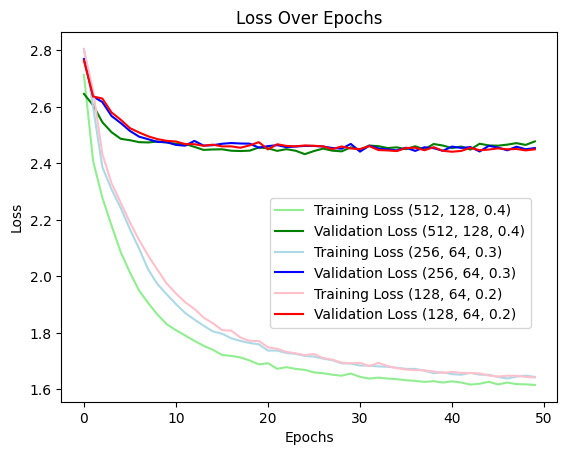

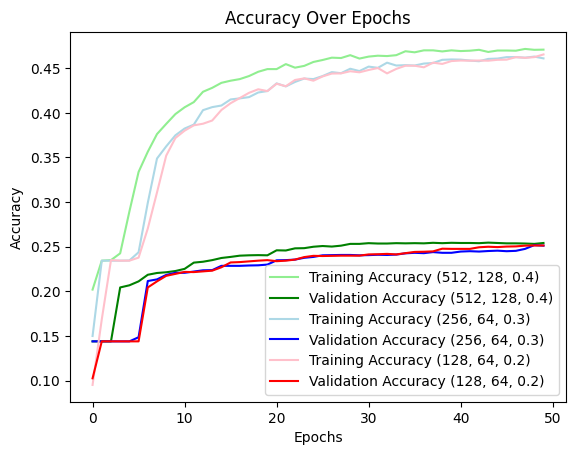

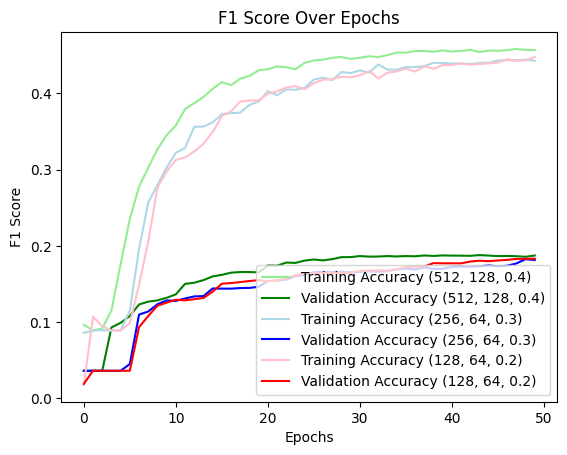

In [ ]:
print(labels)
print(len(labels))
print(Y_train)
labels_integers = [float(i) for i in range(0, 17)]

def check_simple_models(train_X,train_Y,validation_X,validation_Y,test_X,test_Y):
    global results
    clf = LogisticRegression(solver="sag", random_state = 42)
    clf.fit(train_X, train_Y)

    # to target_names = labels paizei na prepei na to allaksw
    predictions = clf.predict(train_X)
    print(f'Logistic Regression Training Accuracy: {accuracy_score(train_Y, predictions)*100:.2f}%')
    print("Logistic Regression Classification report for Training Data")
    print(predictions)
    print(classification_report(train_Y, predictions,labels=labels))

    predictions = clf.predict(validation_X)
    print(f'Logistic Regression Validation Accuracy: {accuracy_score(validation_Y, predictions)*100:.2f}%')
    print("Logistic Regression Classification report for Validation Data")
    print(classification_report(validation_Y, predictions,labels=labels,target_names=labels))


    predictions = clf.predict(test_X)
    print(f'Logistic Regression Test Accuracy:{accuracy_score(test_Y, predictions)*100:.2f}%')
    print("Logistic Regression Classification report for Test Data")
    print(classification_report(test_Y, predictions,labels=labels, target_names=labels))


    baseline = DummyClassifier(strategy='most_frequent')
    baseline.fit(train_X,train_Y)

    predictions = baseline.predict(train_X)
    score = accuracy_score(train_Y, predictions)
    print("Majority Classifier Train accuracy: {:.2f}%".format(score*100))

    predictions_val = baseline.predict(validation_X)
    score = accuracy_score(validation_Y,predictions_val)
    print("Majority Classifier Validation accuracy: {:.2f}%".format(score*100))


    predictions_test = baseline.predict(test_X)
    score = accuracy_score(test_Y, predictions_test)
    print("Majority Classifier Test accuracy: {:.2f}% \n".format(score*100))

    print("Majority Classifier Report for Test Data")
    print(classification_report(test_Y, predictions_test,labels=labels, target_names=labels))

    print("MLP with TF-IDF Features")
    for model_mlp_tf_idf,history,best_model_path in results:
        model_mlp_tf_idf.eval()
        model_mlp_tf_idf.to("cpu")
        # For MLP, a complex model it memorises the training data
        pred_training = model_mlp_tf_idf(X_train_tensor)
        y_pred_training = torch.argmax(pred_training,dim=1)
        print(model_mlp_tf_idf)
        print(f"Results in Training Data for MLP with TFIDF Features, trained for 150 epochs")
        print(classification_report(Y_train, y_pred_training,labels=labels, target_names=labels))
        print(f'MLP TF-IDF Train Accuracy: {accuracy_score(Y_train, y_pred_training)*100:.2f}%')

        pred_val = model_mlp_tf_idf(X_val_tensor)
        y_pred_val = torch.argmax(pred_val, dim=1)
        print(model_mlp_tf_idf)
        print(f"Results in Validation Data for MLP with TFIDF Features, trained for 150 epochs")
        print(classification_report(Y_dev, y_pred_val,labels=labels, target_names=labels))

        print(f'MLP TF-IDF Validation Accuracy: {accuracy_score(Y_dev, y_pred_val)*100:.2f}%')

        predictions_test = model_mlp_tf_idf(X_test_tensor)
        y_pred_test = torch.argmax(predictions_test, dim=1)
        print(f'MLP TF-IDF Test Accuracy:{accuracy_score(Y_test, y_pred_test)*100:.2f}%')
        print(classification_report(Y_test, y_pred_test,labels=labels, target_names=labels))
      # For MLPs Only
    histories = list(map(lambda x: x[1],results))
    plot_training_histories(histories,hyper_parameters)

check_simple_models(X_train_svd,Y_train,X_val_svd,Y_dev,X_test_svd,Y_test)

In [ ]:
from collections import Counter


MAX_SEQUENCE_LENGTH = 100
MAX_WORDS = 100000

# Build vocabulary from tokens in X_train_tokenized
all_tokens = [token for sentence in X_train_tokenized for token in sentence]
token_counts = Counter(all_tokens)

# Initialize vocabulary with special tokens <pad> and <unk>
vocab = {"<pad>": 0, "<unk>": 1}

# Sort tokens by frequency in descending order and add to vocab starting from 2
for i, (token, _) in enumerate(token_counts.most_common(MAX_WORDS), start=2):
    vocab[token] = i

# Encode and pad each sentence
def encode_sentence(sentence, vocab, max_length=100):
    # Map each token to its vocabulary ID or <unk> if not in vocab
    encoded = [vocab.get(token, vocab["<unk>"]) for token in sentence]
    # Pad or truncate to max_length
    return encoded[:max_length] + [vocab["<pad>"]] * max(0, max_length - len(encoded))

# Apply encoding and padding to each sentence in X_train_tokenized
train_data = [encode_sentence(sentence, vocab, MAX_SEQUENCE_LENGTH) for sentence in X_train_tokenized]
val_data = [encode_sentence(sentence, vocab, MAX_SEQUENCE_LENGTH) for sentence in X_val_tokenized]
test_data = [encode_sentence(sentence, vocab, MAX_SEQUENCE_LENGTH) for sentence in X_test_tokenized]

In [ ]:
EMBEDDING_DIM = 300
MAX_WORDS = 100000
MAX_SEQUENCE_LENGTH = 300
embedding_matrix = np.zeros((MAX_WORDS+2, EMBEDDING_DIM))

count = 0
for word, i in vocab.items():
    if i > MAX_WORDS:
            continue
    try:
        embedding_matrix[i] = wv[word]
        count+=1
    except:
        pass

#Return the number of the elements that are non-zero.
print(len(np.unique(np.nonzero(embedding_matrix)[0])))
print(count)

print(embedding_matrix.shape)

1238
1238
(100002, 300)


In [ ]:
del wv
del vocab

In [ ]:
train_dataset = TensorDataset(torch.tensor(train_data, dtype = torch.long), torch.tensor(Y_train, dtype = torch.long))
val_dataset = TensorDataset(torch.tensor(val_data, dtype = torch.long), torch.tensor(Y_dev, dtype = torch.long))
test_dataset = TensorDataset(torch.tensor(test_data, dtype = torch.long), torch.tensor(Y_test, dtype = torch.long))

BATCH_SIZE = 256
# Create DataLoader for each dataset
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
EPOCHS=30
MAX_WORDS = 100000
EMBEDDING_DIM = 300
MAX_SEQUENCE_LENGTH = 200

class BiGRU(nn.Module):
    def __init__(self, input_dim, n_classes, hidden_dim, gru_hidden_dim, gru_stacks, matrix_embeddings = None):
        super(BiGRU, self).__init__()

        # dimensions
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.hidden_dim = hidden_dim
        self.gru_hidden_dim = gru_hidden_dim
        self.gru_stacks = gru_stacks

        # Embedding layer
        if matrix_embeddings is not None:
            self.embeddings = nn.Embedding(num_embeddings = MAX_WORDS + 2, embedding_dim = EMBEDDING_DIM, padding_idx=0).from_pretrained(matrix_embeddings)
            self.embeddings.requires_grad = False # Don't change the embedding matrix
        else:
            self.embeddings = nn.Embedding(num_embeddings = MAX_WORDS + 2, embedding_dim = EMBEDDING_DIM, padding_idx=0)
            self.embeddings.requires_grad = True # Learn the embedding matrix

        # GRU layer
        self.bigru = nn.GRU(input_size = self.input_dim,
                            hidden_size = self.gru_hidden_dim,
                            num_layers = self.gru_stacks,
                            bidirectional = True,
                            batch_first = True)

        # Dropout layer
        self.dropout = nn.Dropout(0.33)

        # Dense layer
        self.dense1 = nn.Linear(self.gru_hidden_dim * 2, self.hidden_dim) # gru_hidden_dim*2 because we will concatenate the left-to-right and right-to-left final states

        # Classification layer
        self.dense2 = nn.Linear(self.hidden_dim, self.n_classes)

    def forward(self, input):
        # Input shape: (batch_size, sequence_length)
        # Embedding layer
        x = self.embeddings(input.long()) # (batch_size, sequence_length, embedding_dim)
        #
        gru_out, final_state = self.bigru(x) # gru_out (batch_size, sequence_length, 2*gru_hidden_dim)
                                             # final_state (2, batch_size, gru_hidden_dim)

        left_to_right_final_state = final_state[-2, :, :] # Final hidden state of the GRU if you go from left to right (batch_size, gru_hidden_dim)
        right_to_left_final_state = final_state[-1, :, :] # Final hidden state of the GRU if you go from right to left (batch_size, gru_hidden_dim)

        # You can combine the final states in any way you see fit. Here I concatenate them
        final_state_concat = torch.cat((left_to_right_final_state, right_to_left_final_state), dim = 1) # (batch_size, gru_hidden_dim*2)

        # Dense layer 1
        x = F.relu(self.dense1(final_state_concat)) # (batch_size, sequence_length, hidden_dim)
        # Dropout
        x = self.dropout(x) # (batch_size, hidden_dim)
        # Output layer
        logits = self.dense2(x) # (batch_size, sequence_length, n_classes)

        return logits

In [ ]:
DENSE = 16
GRU_SIZE = 32
GRU_STACKS = 1
rnn_params = [(16,32,1),(16,32,2),(8,16,1)]

rnn_models = []
for hid_dim,gru_hid_dim,gru_stack in rnn_params:
    bigru = BiGRU(input_dim=EMBEDDING_DIM,
              n_classes=len(labels),
              matrix_embeddings=torch.tensor(embedding_matrix, dtype = torch.float32),
              hidden_dim=hid_dim,
              gru_hidden_dim=gru_hid_dim,
              gru_stacks = gru_stack)
    rnn_models.append(bigru)

In [ ]:
rnn_results = []

In [ ]:

for pos,model in enumerate(rnn_models):
    torch.manual_seed(1)
    model.to(device)

    optimizer = Adam(model.parameters(), lr = 0.01) ## here we're creating an optimizer to train the neural network.
                                                ## NOTE: There are a bunch of different ways to optimize a neural network.
                                                ## In this example, we'll use Adam. .

    criterion = nn.CrossEntropyLoss()

    epochs=10
    #best_f1 = 0
    best_val_loss = float("inf") # Initialize to a high value to track the lowest validation loss
    best_model_path = None  # To keep track of the previous best model file

    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'train_f1_score': [], 'val_f1_score': []}

    start_training_time = time.time()

    ## this is the optimization loop. Each time the optimizer sees all of the training data is called an "epoch".
    for epoch in range(epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        train_outputs = []
        train_labels = []

        ## this internal loop is where the optimizer sees all of the training data and where we
        ## calculate the total_loss for all of the training data.
        for batch in train_loader:

            features, labels = batch
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()  # Zero the gradients

            # Forward pass
            outputs = model(features)

            # Calculate the loss with class indices (not one-hot)
            loss = criterion(outputs, labels)  # labels should be class indices, not one-hot
            loss.backward()  # Backward pass
            optimizer.step()  # Optimize

            running_loss += loss.item()

            train_outputs.append(outputs)
            train_labels.append(labels)



        # Concatenate all outputs and labels
        train_outputs = torch.cat(train_outputs)
        train_labels = torch.cat(train_labels)

        # Get label indices
        #train_classes = torch.argmax(train_labels, dim = 1)
        train_classes = train_labels

        # Get predicted class indices
        train_predicted_classes = torch.argmax(train_outputs, dim=1)

        train_loss = running_loss / len(train_loader)
        train_accuracy = accuracy_score(train_classes.cpu(), train_predicted_classes.cpu())
        train_f1_score = f1_score(train_classes.cpu(), train_predicted_classes.cpu(), average='weighted')
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['train_f1_score'].append(train_f1_score)


        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_loss}")


        # Validation phase
        model.eval()  # Set the model to evaluation mode
        val_running_loss = 0.0
        all_outputs = []
        all_labels = []

        with torch.no_grad():
            for features, labels in val_loader:
                features = features.to(device)
                labels = labels.to(device)
                outputs = model(features)
                loss = criterion(outputs, labels)  # Validation loss
                val_running_loss += loss.item()

                all_outputs.append(outputs)
                all_labels.append(labels)

        # Concatenate all outputs and labels
        all_outputs = torch.cat(all_outputs)
        all_labels = torch.cat(all_labels)

        # Get label indices
        #true_classes = torch.argmax(all_labels, dim=1)
        true_classes = all_labels

        # Get predicted class indices
        predicted_classes = torch.argmax(all_outputs, dim=1)

        # Calculate metrics on the entire validation set
        val_accuracy = accuracy_score(true_classes.cpu(), predicted_classes.cpu())
        val_f1 = f1_score(true_classes.cpu(), predicted_classes.cpu(), average='weighted')

        # Append to history
        val_loss = val_running_loss / len(val_loader)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_f1_score'].append(val_f1)

        # Print validation metrics
        print(f"Validation Loss: {val_loss}")
        print(f"Validation Accuracy: {val_accuracy:.4f}, F1 Score: {val_f1:.4f}")

        # Save checkpoint at the lowest validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            new_model_path = f'rnn_{pos}_best_model_epoch_{epoch+1}.pth'

            # Delete the previous best model if it exists
            if best_model_path is not None:
                os.remove(best_model_path)

            # Save the new best model
            torch.save(model.state_dict(), new_model_path)
            best_model_path = new_model_path  # Update the best model path
            #print(f"Checkpoint saved at epoch {epoch+1} with F1: {val_f1:.4f}")

    print("Training complete!")
    rnn_results.append((model,history,best_model_path))
    end_training_time = time.time()



Epoch 1/10, Training Loss: 2.3986032605171204
Validation Loss: 2.504184341430664
Validation Accuracy: 0.2274, F1 Score: 0.1195
Epoch 2/10, Training Loss: 1.8827187776565553
Validation Loss: 2.4812127590179442
Validation Accuracy: 0.2634, F1 Score: 0.1875
Epoch 3/10, Training Loss: 1.6034529268741609
Validation Loss: 2.5304086804389954
Validation Accuracy: 0.2806, F1 Score: 0.2176
Epoch 4/10, Training Loss: 1.5010799944400788
Validation Loss: 2.543699252605438
Validation Accuracy: 0.2810, F1 Score: 0.2185
Epoch 5/10, Training Loss: 1.434618926048279
Validation Loss: 2.561584937572479
Validation Accuracy: 0.2840, F1 Score: 0.2248
Epoch 6/10, Training Loss: 1.395420455932617
Validation Loss: 2.639876592159271
Validation Accuracy: 0.2878, F1 Score: 0.2328
Epoch 7/10, Training Loss: 1.3685663044452667
Validation Loss: 2.676769661903381
Validation Accuracy: 0.2852, F1 Score: 0.2272
Epoch 8/10, Training Loss: 1.3526025891304017
Validation Loss: 2.6707659363746643
Validation Accuracy: 0.2896, 

In [ ]:
print(len(rnn_results))

NameError: name 'rnn_results' is not defined

In [ ]:
print("-------------------------------------------------------------------------------------------------------------------------")

for pos,(model,history,best_model_path) in enumerate(rnn_results):
    #model.load_state_dict(torch.load(best_model_path, weights_only = True))
    params = rnn_params[pos]
    print("BiGRU model with params: ",params)
    # Set the model to evaluation mode
    model.eval()
    model.to("cpu")
    # should be copied from above for some reason as the order varies from execution to execution
    targets = ['ADP', 'NUM', 'PROPN', 'AUX', 'DET', 'PART', 'ADV', 'PUNCT', 'PRON', 'X', 'SYM', 'INTJ', 'ADJ', 'SCONJ', 'CCONJ', 'VERB', 'NOUN']
    # to montelo provlepei arithmous,
    print("====Training====")
    predictions = model(torch.tensor(train_data,dtype = torch.long))
    y_predictions = torch.argmax(predictions,dim=1)
    print(f'Training Accuracy: {accuracy_score(Y_train, y_predictions)*100:.2f}%')
    print(classification_report(Y_train, y_predictions,labels=targets,target_names=targets))
    print("==========")

    print("======Validation=======")
    pred_val = model(torch.tensor(val_data, dtype = torch.long))
    y_pred_val = torch.argmax(pred_val, dim=1)
    print(f'Validation Accuracy: {accuracy_score(Y_dev, y_pred_val)*100:.2f}%')
    print(classification_report(Y_dev, y_pred_val,target_names=targets))
    print("==========")

    print("======Test=======")
    predictions_test = model(torch.tensor(test_data, dtype = torch.long))
    y_pred_test = torch.argmax(predictions_test, dim=1)
    print(f'Test Accuracy:{accuracy_score(Y_test, y_pred_test)*100:.2f}%')
    print(classification_report(Y_test, y_pred_test,target_names=targets))
    print("==========")



-------------------------------------------------------------------------------------------------------------------------
BiGRU model with params:  (16, 32, 1)
====Training====
Training Accuracy: 59.78%
              precision    recall  f1-score   support

         ADP       0.00      0.00      0.00         0
         NUM       0.00      0.00      0.00         0
       PROPN       0.00      0.00      0.00         0
         AUX       0.00      0.00      0.00         0
         DET       0.00      0.00      0.00         0
        PART       0.00      0.00      0.00         0
         ADV       0.00      0.00      0.00         0
       PUNCT       0.00      0.00      0.00         0
        PRON       0.00      0.00      0.00         0
           X       0.00      0.00      0.00         0
         SYM       0.00      0.00      0.00         0
        INTJ       0.00      0.00      0.00         0
         ADJ       0.00      0.00      0.00         0
       SCONJ       0.00      0.00      0

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

Validation Accuracy: 28.84%
              precision    recall  f1-score   support

         ADP       0.00      0.00      0.00        62
         NUM       1.00      0.01      0.01       332
       PROPN       0.00      0.00      0.00       152
         AUX       0.00      0.00      0.00        10
         DET       1.00      0.08      0.15       229
        PART       0.00      0.00      0.00       126
         ADV       0.00      0.00      0.00       452
       PUNCT       0.46      0.02      0.04       481
        PRON       0.80      0.20      0.31       225
           X       0.89      0.21      0.34       145
         SYM       0.00      0.00      0.00        74
        INTJ       1.00      0.04      0.08       315
         ADJ       0.86      0.31      0.45       289
       SCONJ       0.20      1.00      0.34       870
       CCONJ       0.83      0.33      0.47       720
        VERB       0.93      0.24      0.38       513
        NOUN       1.00      0.80      0.89         5

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Accuracy:26.86%
              precision    recall  f1-score   support

         ADP       0.00      0.00      0.00        50
         NUM       1.00      0.01      0.01       381
       PROPN       1.00      0.01      0.01       158
         AUX       0.00      0.00      0.00        27
         DET       0.91      0.04      0.08       243
        PART       0.00      0.00      0.00        74
         ADV       0.00      0.00      0.00       362
       PUNCT       0.54      0.02      0.04       562
        PRON       0.79      0.22      0.35       238
           X       0.95      0.40      0.56       154
         SYM       0.00      0.00      0.00        72
        INTJ       0.64      0.04      0.07       392
         ADJ       0.87      0.33      0.48       273
       SCONJ       0.18      1.00      0.30       769
       CCONJ       0.83      0.25      0.39       761
        VERB       0.95      0.28      0.44       467
        NOUN       1.00      0.35      0.52        17

    a

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


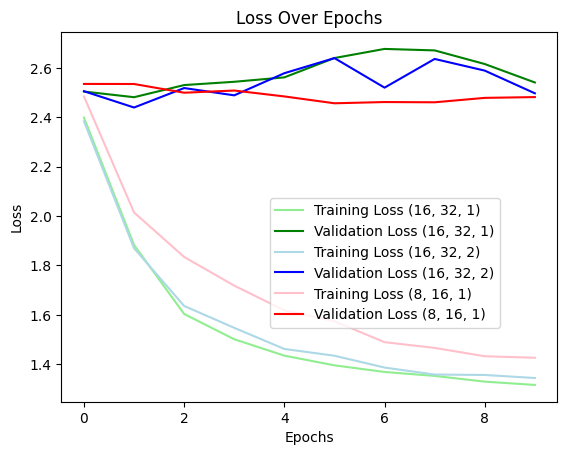

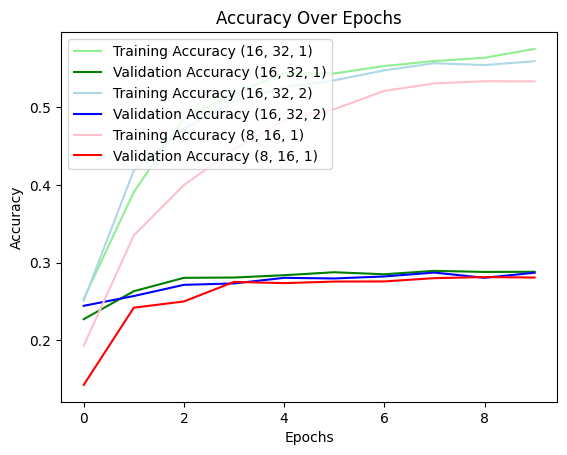

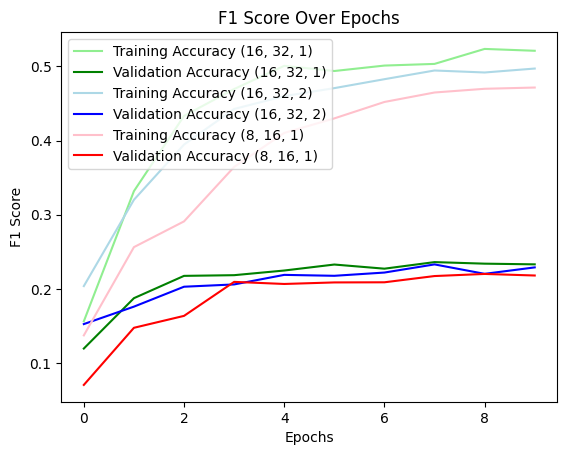

In [ ]:
histories = list(map(lambda x: x[1],rnn_results))
plot_training_histories(histories,rnn_params)
